In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, glob, os
import scipy.stats as stats, scipy.io as sio
from statsmodels.stats.multitest import fdrcorrection


### Objective
0. Run after neur3.ipynb
1. Visualize trial contrasted PSTH for example patient
2. Encoding analyses across patients

### epoch & contrast data

In [2]:
epochs = ['baseline', 'stim', 'delay', 'response', 'feedback']
epoch, contrast = 'stim', 'boundary_context'
normalize = False

per epoch, get trial ids for contrasts in variable of interest, and assign labels

In [3]:
def get_contrast_in_epoch(psychopy_df, contrast, verbose=True):
    ''' split pre-loaded epoch arrays by contrast,
    return list of trial indices for each contrast group and their labels '''

    cont_trials, cont_labels = [], []

    if contrast == 'valence':
        cont_trials.append(psychopy_df[psychopy_df['stim_pos_aligned'] > psychopy_df['div_pos_aligned']].index)
        cont_trials.append(psychopy_df[psychopy_df['stim_pos_aligned'] < psychopy_df['div_pos_aligned']].index)
        cont_labels += ['gain', 'loss']
    elif contrast == 'shape':
        cont_trials.append(psychopy_df[psychopy_df['shape'] == 'curv'].index)
        cont_trials.append(psychopy_df[psychopy_df['shape'] == 'flat'].index)
        cont_labels += ['curv', 'flat']
    elif contrast == 'ambiguity':
        cont_trials.append(psychopy_df[~psychopy_df['uncertainty']].index)
        cont_trials.append(psychopy_df[psychopy_df['uncertainty']].index)
        cont_labels += ['certain', 'uncertain']
    elif contrast == 'resp_dir':
        cont_trials.append(psychopy_df[psychopy_df['chosen_pos'] > psychopy_df['div_pos']].index)
        cont_trials.append(psychopy_df[psychopy_df['chosen_pos'] < psychopy_df['div_pos']].index)
        cont_labels += ['right', 'left']
    elif contrast == 'normed_RT':
        median_rt = psychopy_df['normed_RT'].median()
        cont_trials.append(psychopy_df[psychopy_df['normed_RT'] <= median_rt].index)
        cont_trials.append(psychopy_df[psychopy_df['normed_RT'] > median_rt].index)
        cont_labels += ['fast', 'slow']
    elif contrast == 'outcome': # feedback
        for val, label in zip([3, 1, -1, -3], ['3 coins', '1 coin', '-1 coin', '-3 coins']):
            cont_trials.append(psychopy_df[psychopy_df['outcome'] == val].index)
            cont_labels.append(label)
    elif contrast == 'boundary_context':
        for cond in ['curv_comp', 'baseline', 'flat_comp']:
            cont_trials.append(psychopy_df[psychopy_df['condition'] == cond].index)
            cont_labels.append(cond)
    elif contrast == 'binarized_context':
        cont_trials.append(psychopy_df[psychopy_df['condition'] == 'baseline'].index)
        cont_trials.append(psychopy_df[psychopy_df['condition'] != 'baseline'].index)
        cont_labels += ['base', 'comp']
    elif contrast == 'baseline vs compressed conditions':
        cont_trials.append(psychopy_df[psychopy_df['condition'] != 'baseline'].index)
        cont_trials.append(psychopy_df[psychopy_df['condition'] == 'baseline'].index)
        cont_labels += ['comp', 'base']
    else:
        raise ValueError(f'Invalid contrast: {contrast}')

    if verbose:
        print(f'contrast: {contrast}')
        print(f'num_trials per group should be ~240/num_contrasts')
    return cont_trials, cont_labels

### loading patient data

In [4]:
psychopy_df = pd.read_csv('../../results/psychopy/all_subjs_clean.csv')
# reorder columns to put trial_key first
psychopy_df = psychopy_df[['trial_key', *psychopy_df.columns.difference(['trial_key'], sort=False)]]

# make a list of patients with any data
patients = psychopy_df['subj'].unique().tolist()
print(patients)

# drop patients without neural data
for patient in [9, 11]: patients.remove(patient)
print(f'neural patients: {patients}\n')

psychopy_df

[9, 11, 12, 18, 21, 22]
neural patients: [12, 18, 21, 22]



,trial_key,dir_flip,sess_flip,chosen_pos_aligned,div_pos_aligned,stim_pos,true_class,pred_class,err_type,invalid,...,frameRate,expStart,Unnamed: 119,chosen_pos,Unnamed: 112,stim_ranks,resp_ranks,stim_ranks_aligned,resp_ranks_aligned,block_name
0,21.0,1.0,NaN,-0.044,-0.0,0.02,1,0,-1,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.044,NaN,42.5,23.5,3.25,-15.75,baseline_1.0
1,39.0,1.0,NaN,0.040,-0.0,0.38,1,1,0,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,-0.040,NaN,78.5,49.0,39.25,9.75,baseline_1.0
2,18.0,0.0,NaN,-0.044,0.0,-0.02,0,0,0,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,-0.044,NaN,38.5,23.5,-0.75,-15.75,baseline_1.0
3,23.0,1.0,NaN,-0.068,-0.0,0.06,1,0,-1,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.068,NaN,46.5,13.5,7.25,-25.75,baseline_1.0
4,38.0,0.0,NaN,0.008,0.0,0.38,1,1,0,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.008,NaN,78.5,36.0,39.25,-3.25,baseline_1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,101.0,1.0,NaN,0.296,0.2,0.22,0,1,1,False,...,60.0,2026-01-01 16h46.37.833115 -0700,NaN,-0.296,NaN,44.5,48.0,5.25,8.75,flat_comp_1.0
1436,84.0,0.0,NaN,-0.160,0.2,-0.10,1,0,-1,False,...,60.0,2026-01-01 16h46.37.833115 -0700,NaN,-0.160,NaN,10.5,18.5,-28.75,-20.75,flat_comp_1.0
1437,110.0,0.0,NaN,0.396,0.2,0.30,0,1,1,False,...,60.0,2026-01-01 16h46.37.833115 -0700,NaN,0.396,NaN,60.5,74.5,21.25,35.25,flat_comp_1.0
1438,116.0,0.0,NaN,0.344,0.2,0.38,0,1,1,False,...,60.0,2026-01-01 16h46.37.833115 -0700,NaN,0.344,NaN,76.5,60.5,37.25,21.25,flat_comp_1.0


per patient, load psychopy_df (for trial ids), neuron_df (for region labels), and epoch spike/FR/bin arrays 

In [5]:
def get_pt_metadata(patient, verbose=True):
    ''' load patient-level dataframes: psychopy_df for trial info, neur_df for neuron info '''

    pt_data_dir = f'../../results/2025{patient}/records/processed_data'

    pt_psychopy_df = psychopy_df.loc[psychopy_df['subj'] == patient].reset_index(drop=True)
    pt_neur_df     = pd.read_parquet(f'{pt_data_dir}/df_neurs.parquet')
    pt_num_neurs = len(pt_neur_df)

    if verbose:
        print(f'patient={patient}', f'num_trials={len(pt_psychopy_df)}', f'num_neurons={pt_num_neurs}\n')
    return pt_psychopy_df, pt_neur_df, pt_num_neurs


def get_pt_epoch_spike_data(patient, epoch, verbose=True):
    ''' load spike/FR/bin arrays for a single patient + epoch '''

    pt_data_dir = f'../../results/2025{patient}/records/processed_data'

    pt_epoch_spikes = np.load(f'{pt_data_dir}/{epoch}_spikes.npy', allow_pickle=True)
    pt_epoch_num_spikes = np.array([[len(pt_epoch_spikes[t, n]) for n in range(pt_epoch_spikes.shape[1])]
                                for t in range(pt_epoch_spikes.shape[0])])
    pt_epoch_FRs    = np.load(f'{pt_data_dir}/{epoch}_FRs.npy', allow_pickle=True)
    pt_epoch_bins   = np.load(f'{pt_data_dir}/{epoch}_bin_centers.npy', allow_pickle=True)

    if verbose:
        print(f'patient={patient}, epoch={epoch}')
        print(f'spikes (trials, neurons): {pt_epoch_spikes.shape}')
        print(f'FRs (trials, neurons, bins): {pt_epoch_FRs.shape}')
        print(f'bins (bins, ): {pt_epoch_bins.shape}\n')

    return pt_epoch_spikes, pt_epoch_num_spikes, pt_epoch_FRs, pt_epoch_bins

### choose patient, epoch, contrast, and normalization params

In [6]:
# patient data
patient = 18
pt_psychopy_df, pt_neur_df, pt_num_neurs = get_pt_metadata(patient)

# epoch data
epoch = 'stim'
pt_epoch_spikes, pt_epoch_num_spikes, pt_epoch_FRs, pt_epoch_bins = get_pt_epoch_spike_data(patient, epoch)

# contrast data
contrast = 'binarized_context'
cont_trials, cont_labels = get_contrast_in_epoch(pt_psychopy_df, contrast)

# normalization data
if normalize:
    _, _, baseline_FRs, _ = get_pt_epoch_spike_data(patient, 'baseline')
    normed_FRs = pt_epoch_FRs - baseline_FRs.mean(axis=0, keepdims=True)
    yaxis_lab = 'norm. '
    print('\nnormalizing')
else:
    normed_FRs, yaxis_lab = pt_epoch_FRs.copy(), ''
    print('\nnot normalizing')

patient=18 num_trials=240 num_neurons=12

patient=18, epoch=stim
spikes (trials, neurons): (240, 12)
FRs (trials, neurons, bins): (240, 12, 125)
bins (bins, ): (125,)

contrast: binarized_context
num_trials per group should be ~240/num_contrasts

not normalizing


### 1. contrasted rasters + PSTHs

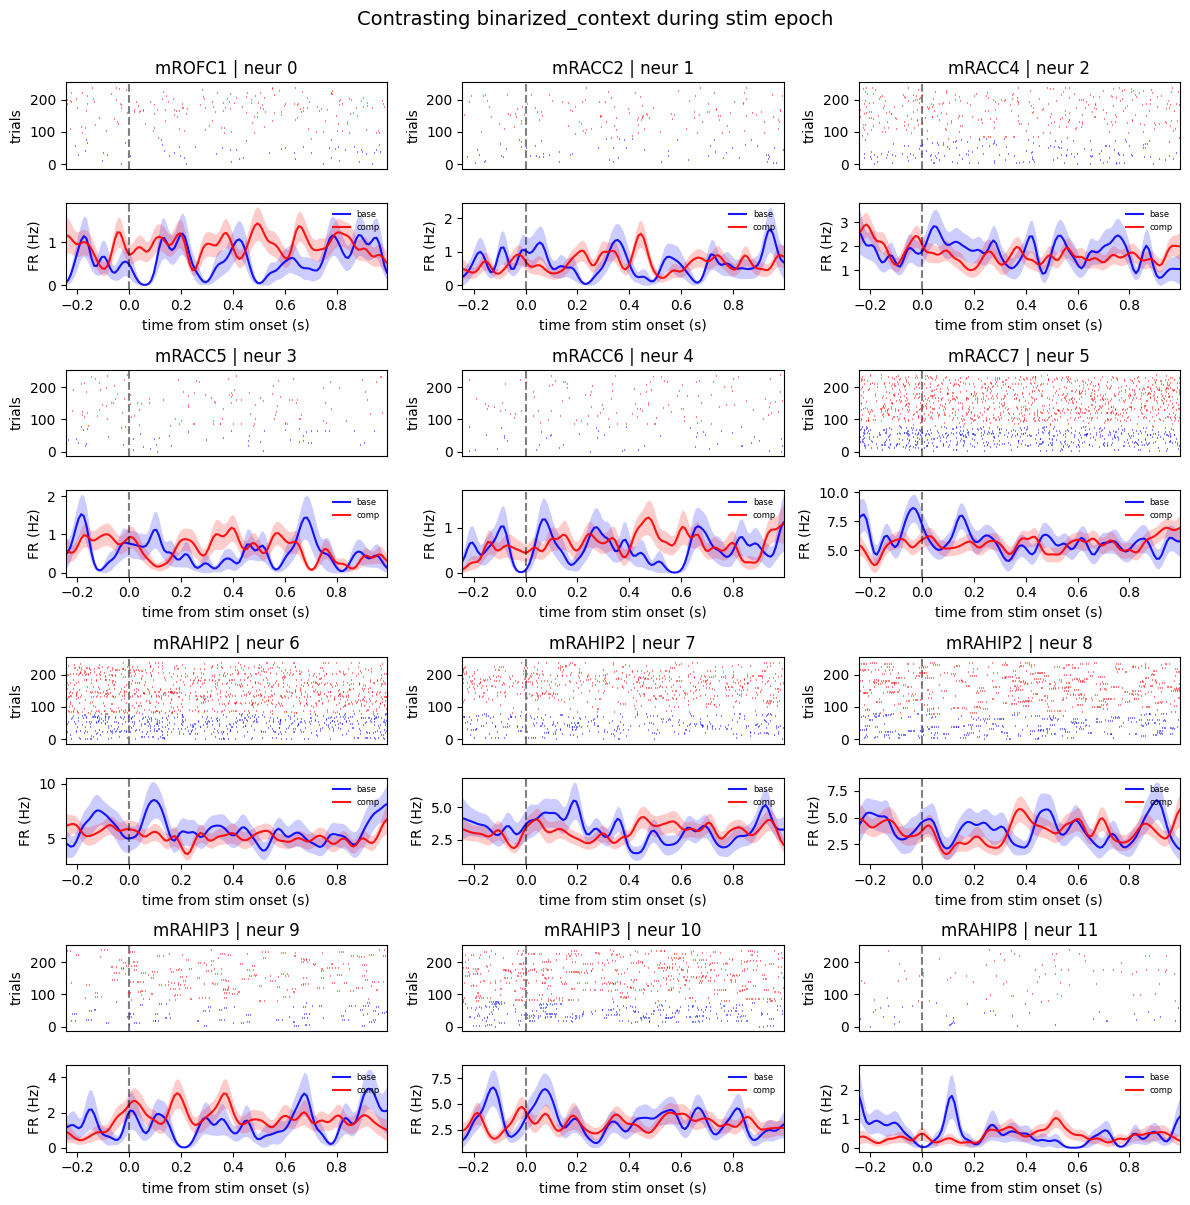

In [7]:
# plot
n_cols = 3
n_rows = int(np.ceil(pt_num_neurs / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axs, ax_idx = axs.flatten(), 0
colors = ['b', 'r', 'g', 'k'] # contrast colors

for neur_id in range(pt_num_neurs):
    if ax_idx >= len(axs): break

    # reconfigure each neur's subplot into 2 rows: raster on top, psth on bottom
    ss = axs[ax_idx].get_subplotspec()
    axs[ax_idx].remove()

    # create new subplotspec for raster and psth
    gs = ss.subgridspec(2, 1, height_ratios=[1, 1])
    ax_raster = fig.add_subplot(gs[0])
    ax_psth   = fig.add_subplot(gs[1], sharex=ax_raster)

    # raster
    raster_trial_list, color_trial_list = [], []
    for idx in range(len(cont_labels)):
        raster_trial_list.extend(list(pt_epoch_spikes[cont_trials[idx], neur_id]))
        color_trial_list.extend([colors[idx]] * len(cont_trials[idx]))

    ax_raster.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_raster.eventplot(raster_trial_list, orientation='horizontal', colors=color_trial_list, linewidths=0.8, linelengths=3.0)
    ax_raster.set(title=f"{pt_neur_df['region'].iloc[neur_id]} | neur {neur_id}", ylabel='trials')
    ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # psth
    for idx in range(len(cont_labels)):
        cont_data = normed_FRs[cont_trials[idx], neur_id, :]
        mu = cont_data.mean(axis=0)
        sderr = (cont_data.std(axis=0, ddof=1) / np.sqrt(cont_data.shape[0])
                 if cont_data.shape[0] > 1 else np.zeros_like(mu))
        ax_psth.plot(pt_epoch_bins, mu, color=colors[idx], alpha=0.9, label=cont_labels[idx])
        ax_psth.fill_between(pt_epoch_bins, mu - sderr, mu + sderr, color=colors[idx], alpha=0.2, linewidth=0)

    ax_psth.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_psth.set(xlim=(pt_epoch_bins[0], pt_epoch_bins[-1]), ylabel=f'{yaxis_lab}FR (Hz)', xlabel=f'time from {epoch} onset (s)')
    ax_psth.legend(loc='upper right', fontsize=6, frameon=False)

    ax_idx += 1

plt.suptitle(f'Contrasting {contrast} during {epoch} epoch', y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

### 2. encoding across patients

In [10]:
epoch, contrast, alpha = 'stim', 'binarized_context', 0.05

# loop patients: collect raw H stats + p-values
pt_neur_dfs = []
for patient in patients:

    # get patient, epoch, and contrast data
    pt_psychopy_df, pt_neur_df, pt_num_neurs = get_pt_metadata(patient, verbose=False)
    _, pt_epoch_num_spikes, _, _ = get_pt_epoch_spike_data(patient, epoch, verbose=False)
    cont_trials, cont_labels = get_contrast_in_epoch(pt_psychopy_df, contrast, verbose=False)

    # kuskal-wallis
    H_stats, pvals = np.full(pt_num_neurs, np.nan), np.full(pt_num_neurs, np.nan)
    for neur in range(pt_num_neurs):
        contrast_spike_counts = [pt_epoch_num_spikes[cont_trials[i], neur] for i in range(len(cont_labels))]
        H_stats[neur], pvals[neur] = stats.kruskal(*contrast_spike_counts)

    # append — stamp neur_idx here so it's guaranteed correct
    pt_neur_df['H'], pt_neur_df['pval'] = H_stats, pvals
    pt_neur_df['pop_neur_idx'] = np.arange(pt_num_neurs)
    pt_neur_dfs.append(pt_neur_df)

all_neurs_df = pd.concat(pt_neur_dfs, ignore_index=True)

# pooled FDR correction across all neurons
all_neurs_df['pval_fdr'] = np.nan
all_neurs_df['significant'], all_neurs_df['pval_fdr'] = fdrcorrection(all_neurs_df['pval'], alpha=alpha)

n_sig = all_neurs_df['significant'].sum()
n_tested = all_neurs_df['pval'].notna().sum()
print(f'epoch={epoch} | contrast={contrast} | alpha={alpha}')
print(f'total neurons: {len(all_neurs_df)}')
print(f'significant (pooled FDR q<{alpha}): {n_sig} / {n_tested} tested')
# print sigfic neurs per patient
print('\n#sigfic neurs by patient')
print(all_neurs_df.groupby('patient')['significant'].sum())
all_neurs_df


epoch=stim | contrast=binarized_context | alpha=0.05
total neurons: 49
significant (pooled FDR q<0.05): 3 / 49 tested

#sigfic neurs by patient
patient
12    3
18    0
21    0
22    0
Name: significant, dtype: int64


,patient,chanID,unitID,spikes,num_spikes,FR,keep,merge_cluster,region,x,y,z,H,pval,pop_neur_idx,pval_fdr,significant
0,12,98,1543/1583,"[4.070566666666667, 12.215633333333335, 12.364...",5701,3.525639,1.0,1.0,mLOFC2,-0.111605,42.570655,-15.682235,1.622903,0.202688,0,0.472938,False
1,12,99,703,"[17.702133333333336, 21.486933333333337, 22.60...",888,0.560458,1.0,NaN,mLOFC3,-0.111605,41.371482,-15.682235,0.016955,0.896400,1,0.921106,False
2,12,101,952,"[18.244333333333337, 20.953133333333337, 21.33...",1865,1.176957,1.0,NaN,mLOFC5,-1.311382,42.570655,-15.682235,0.293603,0.587921,2,0.796673,False
3,12,102,2477,"[18.131033333333335, 18.393666666666668, 18.54...",10843,6.764394,1.0,NaN,mLOFC6,-2.511159,42.570655,-15.682235,0.818523,0.365612,3,0.577904,False
4,12,102,2460/2475,"[2.2395, 2.7039, 17.368133333333336, 18.0163, ...",7997,4.939413,1.0,2.0,mLOFC6,-2.511159,42.570655,-15.682235,11.941886,0.000549,4,0.013447,True
5,12,104,2349/2405,"[5.8953, 13.255100000000002, 17.28773333333333...",9140,5.658967,1.0,3.0,mLOFC8,-2.511159,41.371482,-15.682235,0.189154,0.663622,5,0.833781,False
6,12,104,2410,"[2.8733333333333335, 3.5848333333333335, 3.852...",2370,1.465269,1.0,NaN,mLOFC8,-2.511159,41.371482,-15.682235,3.785317,0.051704,6,0.230318,False
7,12,106,2448/2455,"[1.5377333333333334, 1.8225333333333336, 2.531...",23408,14.457860,1.0,4.0,mLACC2,-1.311382,32.977269,18.278047,1.403186,0.236191,7,0.503189,False
8,12,108,1567,"[4.591233333333334, 18.345733333333335, 20.948...",3100,1.918483,1.0,NaN,mLACC4,-0.111605,34.176443,18.278047,2.204857,0.137577,8,0.472938,False
9,12,109,1760/1763,"[17.901433333333337, 18.007733333333334, 19.13...",10949,6.829526,1.0,5.0,mLACC5,-2.511159,34.176443,18.278047,8.840350,0.002946,9,0.048125,True


### plot only significant neurons

Plotting 3 significant neurons across 1 patients


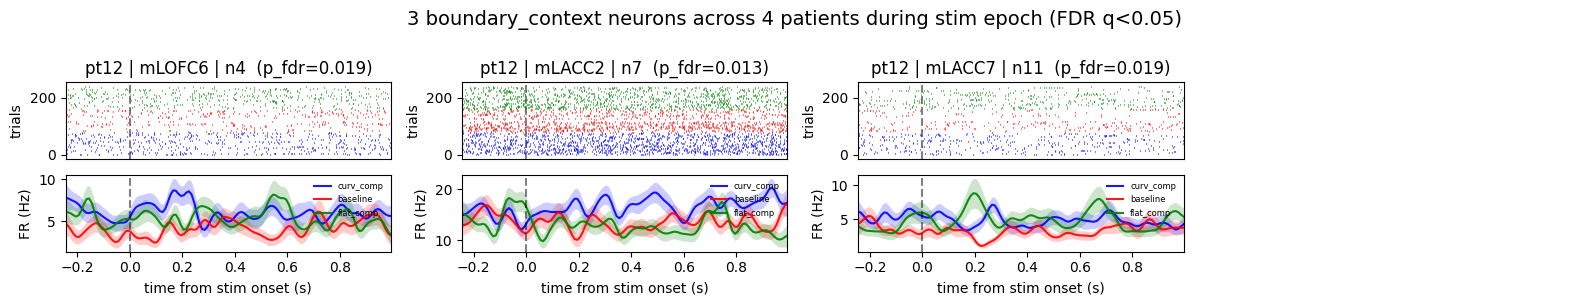

In [9]:
# Raster + PSTH for significant neurons across all patients
# Uses epoch, contrast, alpha, and all_neurs_df from the encoding cell above

colors = ['b', 'r', 'g', 'k']

# neur_idx was stamped in the encoding loop — no recomputation needed
sig_df = all_neurs_df[all_neurs_df['significant']].copy().reset_index(drop=True)
print(f'Plotting {len(sig_df)} significant neurons across {sig_df["patient"].nunique()} patients')

# load per-patient data
_cache = {}
for pt in patients:
    _pt_psychopy_df, _, _ = get_pt_metadata(pt, verbose=False)
    _pt_spikes, _, _pt_FRs, _pt_bins = get_pt_epoch_spike_data(pt, epoch, verbose=False)
    _pt_cont_trials, _pt_cont_labels = get_contrast_in_epoch(_pt_psychopy_df, contrast, verbose=False)
    _cache[pt] = (_pt_spikes, _pt_FRs, _pt_bins, _pt_cont_trials, _pt_cont_labels)

n_cols = 4
n_rows = max(1, int(np.ceil(len(sig_df) / n_cols)))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axs = np.array(axs).flatten()

for ax_idx, (_, row) in enumerate(sig_df.iterrows()):
    pt      = row['patient']
    neur_id = int(row['pop_neur_idx'])
    pt_spikes, pt_FRs, pt_bins, pt_cont_trials, pt_cont_labels = _cache[pt]

    # split ax into raster (top) + psth (bottom)
    ss = axs[ax_idx].get_subplotspec()
    axs[ax_idx].remove()
    gs = ss.subgridspec(2, 1, height_ratios=[1, 1])
    ax_raster = fig.add_subplot(gs[0])
    ax_psth   = fig.add_subplot(gs[1], sharex=ax_raster)

    # raster
    raster_trial_list, color_trial_list = [], []
    for idx in range(len(pt_cont_labels)):
        raster_trial_list.extend(list(pt_spikes[pt_cont_trials[idx], neur_id]))
        color_trial_list.extend([colors[idx]] * len(pt_cont_trials[idx]))

    ax_raster.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_raster.eventplot(raster_trial_list, orientation='horizontal', colors=color_trial_list,
                        linewidths=0.8, linelengths=3.0)
    ax_raster.set(title=f"pt{pt} | {row['region']} | n{neur_id}  (p_fdr={row['pval_fdr']:.3f})",
                  ylabel='trials')
    ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # psth
    for idx in range(len(pt_cont_labels)):
        cont_data = pt_FRs[pt_cont_trials[idx], neur_id, :]
        mu     = cont_data.mean(axis=0)
        sderr  = (cont_data.std(axis=0, ddof=1) / np.sqrt(cont_data.shape[0])
                  if cont_data.shape[0] > 1 else np.zeros_like(mu))
        ax_psth.plot(pt_bins, mu, color=colors[idx], alpha=0.9, label=pt_cont_labels[idx])
        ax_psth.fill_between(pt_bins, mu - sderr, mu + sderr, color=colors[idx], alpha=0.2, linewidth=0)

    ax_psth.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_psth.set(xlim=(pt_bins[0], pt_bins[-1]),
                ylabel='FR (Hz)', xlabel=f'time from {epoch} onset (s)')
    ax_psth.legend(loc='upper right', fontsize=6, frameon=False)

# hide unused axes
for ax_idx in range(len(sig_df), len(axs)):
    axs[ax_idx].axis('off')

plt.suptitle(f'{len(sig_df)} {contrast} neurons across {len(patients)} patients during {epoch} epoch (FDR q<{alpha})', y=1.0, fontsize=14)
plt.tight_layout()
plt.show()
